In [35]:
from pathlib import Path
import json
import datetime
import re
import hashlib
import os
import pickle as pkl
import joblib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import ruptures as rpt
from scipy.stats import skew, kurtosis
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, SequentialFeatureSelector
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from tqdm.auto import tqdm
from sklearn.utils import resample
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_score, recall_score,
    f1_score, make_scorer, get_scorer, roc_curve
)
from sklearn.calibration import calibration_curve

In [36]:
variables_finales = [
    'retail_price',
    'pre_release_premium_pct',
    'brand_historical_rate',
    'brand_Jordan',
    'num_pre_release_points',
]

cols_scale_lin = [i for i in variables_finales if i != 'brand_Jordan']

TARGET = 'is_above_retail_90d'

In [37]:
root = Path('..')
data_folder = Path('data')
f_d = Path('ready_data.pkl')
lin = Path('ref_test_lin.pkl')

In [38]:
features = joblib.load(root/data_folder/f_d)
ref_test_lin = joblib.load(root/data_folder/lin)['ref_test_lin']

In [39]:
features.keys()
train_lin = features['train_data']
test_lin = features['test_data']

In [40]:
scaler_lin = RobustScaler()
train_lin[cols_scale_lin] = scaler_lin.fit_transform(train_lin[cols_scale_lin])
test_lin[cols_scale_lin]  = scaler_lin.transform(test_lin[cols_scale_lin])

In [ ]:
train_lin = pd.get_dummies(train_lin, columns=['brand_grouped'], prefix='brand', drop_first=True)
test_lin  = pd.get_dummies(test_lin,  columns=['brand_grouped'], prefix='brand', drop_first=True)

train_lin, test_lin = train_lin.align(test_lin, join='left', axis=1, fill_value=0)

dummy_cols = [c for c in train_lin.columns if c.startswith('brand_') and c != 'brand_historical_rate']
train_lin[dummy_cols] = train_lin[dummy_cols].astype(int)
test_lin[dummy_cols]  = test_lin[dummy_cols].astype(int)

# ------- dates ---------
def add_cyclical_features(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)
    return df

for d in [train_lin, test_lin]:
    add_cyclical_features(d, 'release_month', 12)
    add_cyclical_features(d, 'release_quarter', 4)
    add_cyclical_features(d, 'release_dow', 7)

train_lin = train_lin.drop(columns=['release_month', 'release_quarter', 'release_dow'])
test_lin  = test_lin.drop(columns=['release_month', 'release_quarter', 'release_dow'])

In [42]:
train_lin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3271 entries, 0 to 3270
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        3271 non-null   object        
 1   retail_price                 3271 non-null   float64       
 2   release_date                 3271 non-null   datetime64[ns]
 3   brand                        3271 non-null   object        
 4   pre_release_premium_pct      3271 non-null   float64       
 5   is_above_retail_90d          3271 non-null   object        
 6   has_pre_release_speculation  3271 non-null   bool          
 7   num_pre_release_points       3271 non-null   float64       
 8   pre_release_volatility       3271 non-null   float64       
 9   pre_release_trend            3271 non-null   float64       
 10  days_speculation_window      3271 non-null   float64       
 11  release_year                 3271 non-null   int

In [43]:
X_train = train_lin[variables_finales].values
y_train = train_lin['is_above_retail_90d'].astype(int).values
X_test  = test_lin[variables_finales].values
y_test  = test_lin['is_above_retail_90d'].astype(int).values

In [44]:
train_lin[variables_finales].columns

Index(['retail_price', 'pre_release_premium_pct', 'brand_historical_rate',
       'brand_Jordan', 'num_pre_release_points'],
      dtype='object')

In [45]:
train_lin[variables_finales]

,retail_price,pre_release_premium_pct,brand_historical_rate,brand_Jordan,num_pre_release_points
0,1.076923,3.152273,2.768992,0,0.000000
1,1.076923,11.149545,2.768992,0,0.000000
2,-0.923077,0.000000,2.768992,0,-0.333333
3,-0.923077,0.000000,2.768992,0,-0.333333
4,-0.923077,0.000000,2.768992,0,-0.333333
...,...,...,...,...,...
3266,1.076923,0.000000,-0.045314,0,-0.333333
3267,0.461538,0.000000,-0.038859,0,-0.333333
3268,-0.076923,0.891034,-0.913954,0,6.666667
3269,-0.307692,2.923077,-0.907353,0,7.000000


In [46]:
modelo_final = LogisticRegression(
    C=0.1,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
modelo_final.fit(X_train, y_train)

d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Ta

═════════════════════════════════════════════════════════════════
UMBRALES ÓPTIMOS POR CRITERIO DE NEGOCIO
═════════════════════════════════════════════════════════════════

  A) Máximo F1:
     threshold=0.33 | P=0.592 R=0.791 F1=0.677 | predice 478 pares como 'above retail'

  B) Recall ≥ 0.60 (no perder pares buenos):
     threshold=0.43 | P=0.642 R=0.601 F1=0.620 | predice 335 pares como 'above retail'

  C) Precision ≥ 0.75 (no comprar pares malos):
     threshold=0.55 | P=0.812 R=0.302 F1=0.440 | predice 133 pares como 'above retail'

═════════════════════════════════════════════════════════════════
ANÁLISIS DE RANKING — tasa real en top-K pares
═════════════════════════════════════════════════════════════════
  (Tasa base en test: 43.8%)

       K  Above retail en top-K     Lift
  ────────────────────────────────────────
      10                  90.0%     2.06x
      25                  96.0%     2.19x
      50                  94.0%     2.15x
     100                  85.0%   

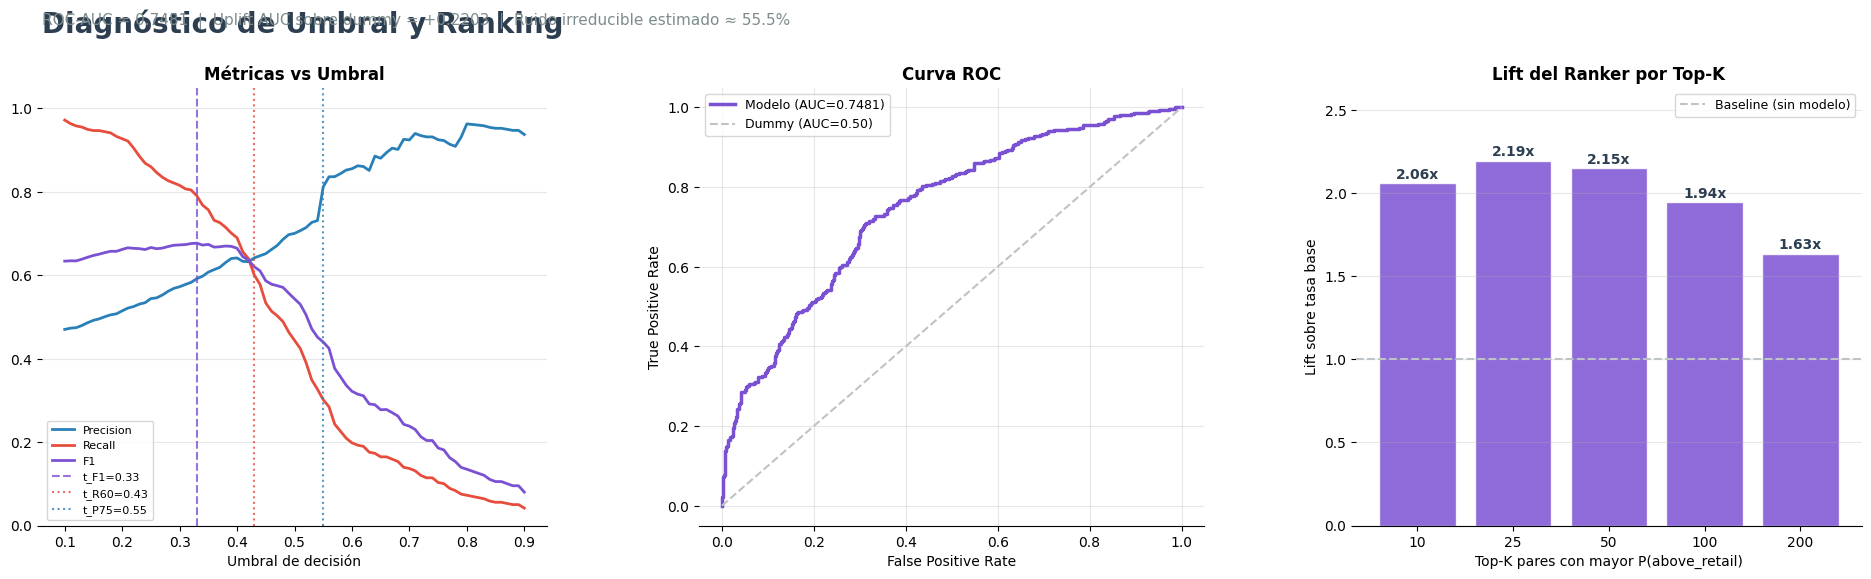

In [47]:
# ============================================================
# 1. PROBABILIDADES DEL MODELO SOBRE TEST
# ============================================================
y_proba = modelo_final.predict_proba(X_test)[:, 1]


# Simulación de Umbrales

thresholds = np.arange(0.10, 0.91, 0.01)
resultados_thresh = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    pred_positivos = y_pred_t.sum()
    if pred_positivos == 0:
        continue
    resultados_thresh.append({
        'threshold':  t,
        'precision':  precision_score(y_test, y_pred_t, zero_division=0),
        'recall':     recall_score(y_test, y_pred_t, zero_division=0),
        'f1':         f1_score(y_test, y_pred_t, zero_division=0),
        'n_predicted_positive': pred_positivos,
    })

df_thresh = pd.DataFrame(resultados_thresh)

# Umbral A: máximo F1
idx_f1 = df_thresh['f1'].idxmax()
t_f1   = df_thresh.loc[idx_f1]

# Umbral B: recall >= 0.60, mayor precision posible
candidates_b = df_thresh[df_thresh['recall'] >= 0.60]
t_recall = candidates_b.loc[candidates_b['precision'].idxmax()] if not candidates_b.empty else None

# Umbral C: precision >= 0.75, mayor recall posible
candidates_c = df_thresh[df_thresh['precision'] >= 0.75]
t_precision = candidates_c.loc[candidates_c['recall'].idxmax()] if not candidates_c.empty else None

print("═" * 65)
print("UMBRALES ÓPTIMOS POR CRITERIO DE NEGOCIO")
print("═" * 65)
print(f"\n  A) Máximo F1:")
print(f"     threshold={t_f1['threshold']:.2f} | "
      f"P={t_f1['precision']:.3f} R={t_f1['recall']:.3f} F1={t_f1['f1']:.3f} | "
      f"predice {t_f1['n_predicted_positive']:.0f} pares como 'above retail'")

if t_recall is not None:
    print(f"\n  B) Recall ≥ 0.60 (no perder pares buenos):")
    print(f"     threshold={t_recall['threshold']:.2f} | "
          f"P={t_recall['precision']:.3f} R={t_recall['recall']:.3f} F1={t_recall['f1']:.3f} | "
          f"predice {t_recall['n_predicted_positive']:.0f} pares como 'above retail'")

if t_precision is not None:
    print(f"\n  C) Precision ≥ 0.75 (no comprar pares malos):")
    print(f"     threshold={t_precision['threshold']:.2f} | "
          f"P={t_precision['precision']:.3f} R={t_precision['recall']:.3f} F1={t_precision['f1']:.3f} | "
          f"predice {t_precision['n_predicted_positive']:.0f} pares como 'above retail'")

# ============================================================
# 3. EL MODELO COMO RANKER — ¿los top-K tienen mayor tasa real?
# ============================================================
df_ranker = pd.DataFrame({
    'proba':         y_proba,
    'real':          y_test,
    'title':         ref_test_lin.loc[test_lin.index, 'title'].values,
}).sort_values('proba', ascending=False).reset_index(drop=True)

K_values = [10, 25, 50, 100, 200]
print("\n" + "═" * 65)
print("ANÁLISIS DE RANKING — tasa real en top-K pares")
print("═" * 65)
print(f"  (Tasa base en test: {y_test.mean():.1%})\n")
print(f"  {'K':>6} {'Above retail en top-K':>22} {'Lift':>8}")
print("  " + "─" * 40)
for k in K_values:
    tasa_k = df_ranker.head(k)['real'].mean()
    lift   = tasa_k / y_test.mean()
    print(f"  {k:>6} {tasa_k:>22.1%} {lift:>8.2f}x")

# ============================================================
# 4. VISUALIZACIÓN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.text(0.06, 0.98, "Diagnóstico de Umbral y Ranking", fontsize=20,
          fontweight='bold', color='#2c3e50', va='top')
fig.text(0.06, 0.955,
          f"ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}  |  "
          f"Uplift AUC sobre dummy = +0.2203  |  "
          f"Ruido irreducible estimado ≈ 55.5%",
          fontsize=11, color='#7f8c8d')

# Panel 1 — Precision / Recall / F1 vs threshold
ax = axes[0]
ax.plot(df_thresh['threshold'], df_thresh['precision'],
        color='#2980b9', linewidth=2, label='Precision')
ax.plot(df_thresh['threshold'], df_thresh['recall'],
        color='#e74c3c', linewidth=2, label='Recall')
ax.plot(df_thresh['threshold'], df_thresh['f1'],
        color='#7b51d3', linewidth=2, label='F1')
ax.axvline(t_f1['threshold'], color='#7b51d3', linestyle='--',
            linewidth=1.5, alpha=0.8, label=f"t_F1={t_f1['threshold']:.2f}")
if t_recall is not None:
    ax.axvline(t_recall['threshold'], color='#e74c3c', linestyle=':',
                linewidth=1.5, alpha=0.8, label=f"t_R60={t_recall['threshold']:.2f}")
if t_precision is not None:
    ax.axvline(t_precision['threshold'], color='#2980b9', linestyle=':',
                linewidth=1.5, alpha=0.8, label=f"t_P75={t_precision['threshold']:.2f}")
ax.set_xlabel('Umbral de decisión')
ax.set_title('Métricas vs Umbral', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
sns.despine(left=True, ax=ax)

# Panel 2 — Curva ROC
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, color='#7b51d3', linewidth=2.5,
        label=f'Modelo (AUC={roc_auc_score(y_test, y_proba):.4f})')
ax.plot([0, 1], [0, 1], color='#bdc3c7', linestyle='--', linewidth=1.5, label='Dummy (AUC=0.50)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
sns.despine(left=True, ax=ax)

# Panel 3 — Lift del ranker por top-K
ax = axes[2]
tasas_k = [df_ranker.head(k)['real'].mean() for k in K_values]
lifts_k = [t / y_test.mean() for t in tasas_k]
ax.bar([str(k) for k in K_values], lifts_k,
        color='#7b51d3', alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='#bdc3c7', linestyle='--', linewidth=1.5, label='Baseline (sin modelo)')
for i, (k, lift) in enumerate(zip(K_values, lifts_k)):
    ax.text(i, lift + 0.03, f'{lift:.2f}x', ha='center', fontsize=10,
            fontweight='bold', color='#2c3e50')
ax.set_xlabel('Top-K pares con mayor P(above_retail)')
ax.set_ylabel('Lift sobre tasa base')
ax.set_title('Lift del Ranker por Top-K', fontweight='bold')
ax.set_ylim(0, max(lifts_k) * 1.2)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
sns.despine(left=True, ax=ax)

plt.subplots_adjust(top=0.85, left=0.06, right=0.97, bottom=0.12, wspace=0.3)
plt.show()

In [53]:
# ============================================================
# 1. CARGAR BUNDLE
# ============================================================
bundle    = joblib.load('bundle_above_retail.pkl')
modelo    = bundle['modelo']
scaler    = bundle['scaler']
variables = bundle['variables']

# Tasas históricas por marca (precalculadas en entrenamiento)
# Si no las tienes en el bundle, agrégalas así:
# bundle['brand_historical_rates'] = train_lin.groupby(
#     df_modelo.loc[train_lin.index, 'brand'])['is_above_retail_90d'].mean().to_dict()
# joblib.dump(bundle, 'bundle_above_retail.pkl')
brand_rates = bundle.get('brand_historical_rates', {
    'Jordan':      0.82,
    'Nike':        0.61,
    'Yeezy':       0.74,
    'Adidas':      0.53,
    'New Balance': 0.58,
    'Puma':        0.41,
    'ASICS':       0.44,
    'Onitsuka':    0.39,
    'Vans':        0.30,
    'Other':       0.45,
})

MARCAS = list(brand_rates.keys())

# ============================================================
# 2. INPUTS DEL USUARIO
# ============================================================
print("=" * 55)
print("  PREDICTOR DE REVENTA — is_above_retail_90d")
print("=" * 55)

# --- Marca ---
print("\nMarcas disponibles:")
for i, m in enumerate(MARCAS, 1):
    print(f"  {i}. {m}")
while True:
    try:
        idx_marca = int(input("\nSelecciona el número de marca: ")) - 1
        marca = MARCAS[idx_marca]
        break
    except (ValueError, IndexError):
        print("  Opción inválida, intenta de nuevo.")

# --- Retail price ---
while True:
    try:
        retail_price = float(input("Precio retail (USD): $"))
        if retail_price > 0:
            break
        print("  Debe ser mayor a 0.")
    except ValueError:
        print("  Ingresa un número válido.")

# --- Pre-release peak ---
print("\n  (Si no hubo especulación pre-lanzamiento, ingresa 0)")
while True:
    try:
        pre_release_peak = float(input("Precio peak pre-lanzamiento (USD): $"))
        if pre_release_peak >= 0:
            break
        print("  Debe ser mayor o igual a 0.")
    except ValueError:
        print("  Ingresa un número válido.")

# --- Num pre-release points ---
while True:
    try:
        num_pre_release_points = int(input("Número de registros de precio pre-lanzamiento: "))
        if num_pre_release_points >= 0:
            break
        print("  Debe ser mayor o igual a 0.")
    except ValueError:
        print("  Ingresa un número entero válido.")

# ============================================================
# 3. DERIVAR FEATURES (igual que en entrenamiento)
# ============================================================
pre_release_premium_pct = (
    (pre_release_peak - retail_price) / retail_price * 100
    if retail_price > 0 and pre_release_peak > 0
    else 0.0
)
brand_historical_rate = brand_rates.get(marca, brand_rates['Other'])
brand_Jordan          = int(marca == 'Jordan')

# ============================================================
# 4. CONSTRUIR VECTOR EN EL ORDEN EXACTO DEL MODELO
# ============================================================
input_dict = {
    'retail_price':             retail_price,
    'pre_release_premium_pct':  pre_release_premium_pct,
    'brand_historical_rate':    brand_historical_rate,
    'brand_Jordan':             brand_Jordan,
    'num_pre_release_points':   num_pre_release_points,
}
X_raw    = pd.DataFrame([input_dict])[variables]
X_scaled = scaler_lin.transform(X_raw[cols_scale_lin])
X_scaled_df = pd.DataFrame(X_scaled, columns=cols_scale_lin, index=X_raw.index)
X_scaled = pd.concat([X_scaled_df, X_raw['brand_Jordan']], axis=1)

# ============================================================
# 5. PREDICCIÓN
# ============================================================
proba     = modelo.predict_proba(X_scaled)[0, 1]
pred_bin  = int(proba >= bundle.get('umbral', 0.43))

# Nivel de confianza
if proba >= 0.85:
    confianza = "MUY ALTA  ✅"
elif proba >= 0.70:
    confianza = "ALTA      ✅"
elif proba >= 0.50:
    confianza = "MEDIA     ⚠️"
else:
    confianza = "BAJA      ❌"

# ============================================================
# 6. OUTPUT
# ============================================================
print("\n" + "=" * 55)
print("  RESUMEN DE INPUTS")
print("=" * 55)
print(f"  Marca:                   {marca}")
print(f"  Retail price:            ${retail_price:,.0f}")
print(f"  Pre-release peak:        ${pre_release_peak:,.0f}")
print(f"  Pre-release premium:     {pre_release_premium_pct:.1f}%  [calculado]")
print(f"  Brand historical rate:   {brand_historical_rate:.1%}  [calculado]")
print(f"  Brand Jordan:            {brand_Jordan}              [calculado]")
print(f"  Num pre-release points:  {num_pre_release_points}")

print("\n" + "=" * 55)
print("  PREDICCIÓN")
print("=" * 55)
print(f"  P(above retail a 90d):   {proba:.1%}")
print(f"  Confianza:               {confianza}")
print(f"  Decisión (t=0.43):       {'ABOVE RETAIL' if pred_bin else 'BELOW RETAIL'}")
print(f"\n  Ranking sugerido:        {'Top candidato 🔥' if proba >= 0.85 else 'Candidato medio ⚠️' if proba >= 0.60 else 'Descartar ❌'}")
print("=" * 55)

  PREDICTOR DE REVENTA — is_above_retail_90d

Marcas disponibles:
  1. Jordan
  2. Nike
  3. Yeezy
  4. Adidas
  5. New Balance
  6. Puma
  7. ASICS
  8. Onitsuka
  9. Vans
  10. Other

  (Si no hubo especulación pre-lanzamiento, ingresa 0)

  RESUMEN DE INPUTS
  Marca:                   Adidas
  Retail price:            $110
  Pre-release peak:        $0
  Pre-release premium:     0.0%  [calculado]
  Brand historical rate:   53.0%  [calculado]
  Brand Jordan:            0              [calculado]
  Num pre-release points:  0

  PREDICCIÓN
  P(above retail a 90d):   0.0%
  Confianza:               BAJA      ❌
  Decisión (t=0.43):       BELOW RETAIL

  Ranking sugerido:        Descartar ❌


d:\Proyectos personales\StockX_scrapper\StockX_Project\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
